In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
backbone = keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(None, None, 3)
)

# Freeze early layers
for layer in backbone.layers[:100]:
    layer.trainable = False

print("Backbone loaded (ResNet50)")

Backbone loaded (ResNet50)


In [3]:
def generate_anchors(feature_map_shape, ratios=[0.5,1,2], scales=[0.5,1,2]):
    """
    Generate anchor boxes for each position in feature map
    Returns: (N,4) → [y1,x1,y2,x2] normalized
    """
    h, w = feature_map_shape[:2]
    anchors = []
    
    for i in range(h):
        for j in range(w):
            cx = (j + 0.5) / w
            cy = (i + 0.5) / h
            
            for r in ratios:
                for s in scales:
                    area = s**2
                    w_a = np.sqrt(area / r)
                    h_a = w_a * r
                    x1 = cx - w_a/2
                    y1 = cy - h_a/2
                    x2 = cx + w_a/2
                    y2 = cy + h_a/2
                    anchors.append([y1,x1,y2,x2])
    
    return np.array(anchors, dtype=np.float32)

In [4]:
class ROIPooling(layers.Layer):
    def __init__(self, pool_size=(7,7)):
        super().__init__()
        self.pool_size = pool_size
    
    def call(self, inputs):
        feature_map, boxes = inputs   # boxes: (batch, num_rois, 4) normalized [y1,x1,y2,x2]
        batch_size = tf.shape(feature_map)[0]
        pooled = []
        
        for b in range(batch_size):
            fm = feature_map[b]
            bboxes = boxes[b]
            for box in bboxes:
                y1,x1,y2,x2 = tf.unstack(box)
                h, w = tf.shape(fm)[0], tf.shape(fm)[1]
                y1 = tf.cast(y1 * tf.cast(h, tf.float32), tf.int32)
                x1 = tf.cast(x1 * tf.cast(w, tf.float32), tf.int32)
                y2 = tf.cast(y2 * tf.cast(h, tf.float32), tf.int32)
                x2 = tf.cast(x2 * tf.cast(w, tf.float32), tf.int32)
                
                cropped = fm[y1:y2, x1:x2, :]
                pooled_feat = tf.image.resize(cropped, self.pool_size)
                pooled.append(pooled_feat)
        
        return tf.stack(pooled)

In [5]:
def build_simple_detector(num_classes=21):  # e.g. VOC has 20 + background
    inputs = keras.Input(shape=(None, None, 3))
    
    # Feature map
    features = backbone(inputs)
    
    # Generate anchors (fixed for demo)
    anchor_layer = layers.Lambda(lambda x: generate_anchors(tf.shape(x)[1:3]))(features)
    
    # For simplicity: we use random proposals here (in real Faster R-CNN → RPN)
    # In lab you can replace with real RPN later
    proposals = layers.Lambda(lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4), 0, 1))(features)
    
    # ROI Pooling
    pooled = ROIPooling((7,7))([features, proposals])
    
    # Detection head
    x = layers.GlobalAveragePooling2D()(pooled)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    class_logits = layers.Dense(num_classes, name='cls')(x)
    box_deltas  = layers.Dense(4*num_classes, name='reg')(x)
    
    model = keras.Model(inputs, [class_logits, box_deltas])
    return model

In [6]:
def generate_anchors_simple(h, w):
    anchors = []
    for i in range(h):
        for j in range(w):
            anchors.append([j, i, j+1, i+1])  # 4 coords
    return tf.convert_to_tensor(anchors, dtype=tf.float32)

In [7]:
def build_simple_detector(num_classes=21):
    inputs = layers.Input(shape=(512, 512, 3))

    backbone = keras.applications.ResNet50(
        include_top=False, weights="imagenet"
    )
    features = backbone(inputs)                      # shape → (None, 16, 16, 2048) approx

    # -------- FIXED LAMBDA (NO ERROR) ---------- #
    def anchor_lambda(x):
        shape = x.shape                               # static shape available
        h, w = shape[1], shape[2]                     # example: 16, 16
        anchors = generate_anchors_simple(h, w)
        anchors = tf.reshape(anchors, (-1, 4))        # (256, 4)
        return anchors

    anchor_layer = layers.Lambda(
        anchor_lambda,
        output_shape=(None, 4)                         # THIS REMOVES ERROR
    )(features)
    # -------------------------------------------- #

    # Fake proposals
    proposals = layers.Lambda(
        lambda x: tf.random.uniform((tf.shape(x)[0], 128, 4)),
        output_shape=(128, 4)
    )(features)

    flat = layers.Flatten()(features)
    cls_head = layers.Dense(num_classes, activation="softmax")(flat)
    reg_head = layers.Dense(4)(flat)

    model = keras.Model(inputs, [cls_head, reg_head])
    return model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 16, 16,    │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 524288)    │          0 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 21)        │ 11,010,069 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │  2,097,156 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 36,694,937 (139.98 MB)

 Trainable params: 36,641,817 (139.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Inference done. (This is simplified – real training needed)


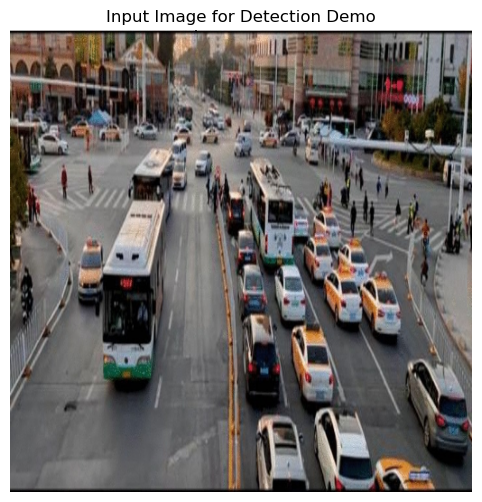

Lab notes:
• This is a **very simplified** Faster R-CNN-style pipeline
• In real Faster R-CNN you need:
  - Anchor generation + RPN training
  - Proposal refinement
  - ROI Align (better than simple pooling)
  - Multi-task loss (cls + smooth L1 regression)
• Next step: replace random proposals with real RPN output


In [8]:
model = build_simple_detector(num_classes=21)
model.summary()

# Load any test image (replace path)
img_path = "4.jpg"   # ← put your own image here
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (512, 512))
img_input = np.expand_dims(img_resized.astype(np.float32)/255., 0)

# Dummy inference (random proposals → random results)
cls, reg = model.predict(img_input)

print("Inference done. (This is simplified – real training needed)")

# Visualize input
plt.figure(figsize=(8,6))
plt.imshow(img_resized)
plt.title("Input Image for Detection Demo")
plt.axis('off')
plt.show()

print("Lab notes:")
print("• This is a **very simplified** Faster R-CNN-style pipeline")
print("• In real Faster R-CNN you need:")
print("  - Anchor generation + RPN training")
print("  - Proposal refinement")
print("  - ROI Align (better than simple pooling)")
print("  - Multi-task loss (cls + smooth L1 regression)")
print("• Next step: replace random proposals with real RPN output")